In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_selection import RFECV
from sklearn.model_selection import StratifiedKFold
import shap
import joblib

In [4]:
# Charger la base complete
df = pd.read_csv(
    "BASE_COMPLETE_4VILLES_2021_2023.csv",
    index_col = "date",
    parse_dates = True
)

print(f"Dimensions : {df.shape}")
print(f"\nColonnes : {list(df.columns)}")
print(f"\nVilles : {df['ville'].unique()}")
print(f"\nPeriode : {df.index.min()} → {df.index.max()}")
print(f"\nValeurs manquantes :\n{df.isnull().sum()}")
print(f"\nApercu :")
print(df.head())

Dimensions : (4380, 15)

Colonnes : ['temp_max', 'temp_min', 'humidite', 'vent', 'rayonnement', 'precipitations', 'doy', 'ET0', 'ETc', 'besoin_irrigation', 'NDVI', 'NDWI', 'SAVI', 'stress_hydrique', 'ville']

Villes : ['Dagana' 'Saint-Louis' 'Podor' 'Matam']

Periode : 2021-01-01 00:00:00 → 2023-12-31 00:00:00

Valeurs manquantes :
temp_max             0
temp_min             0
humidite             0
vent                 0
rayonnement          0
precipitations       0
doy                  0
ET0                  0
ETc                  0
besoin_irrigation    0
NDVI                 0
NDWI                 0
SAVI                 0
stress_hydrique      0
ville                0
dtype: int64

Apercu :
            temp_max  temp_min  humidite  vent  rayonnement  precipitations  \
date                                                                          
2021-01-01     32.38     17.94     39.49  4.31        19.55             0.0   
2021-01-02     30.29     15.04     41.34  3.78        19.86  

In [5]:
df.head()

,temp_max,temp_min,humidite,vent,rayonnement,precipitations,doy,ET0,ETc,besoin_irrigation,NDVI,NDWI,SAVI,stress_hydrique,ville
date,,,,,,,,,,,,,,,
2021-01-01,32.38,17.94,39.49,4.31,19.55,0.0,1,7.930770,9.120385,9.12,0.192361,-0.189550,0.288516,1,Dagana
2021-01-02,30.29,15.04,41.34,3.78,19.86,0.0,2,7.050747,8.108360,8.11,0.192361,-0.189550,0.288516,1,Dagana
2021-01-03,31.85,15.42,36.18,3.18,20.07,0.0,3,6.859433,7.888348,7.89,0.192985,-0.187224,0.289453,1,Dagana
2021-01-04,34.36,16.83,33.69,3.36,20.36,0.0,4,7.591446,8.730163,8.73,0.193610,-0.184898,0.290390,1,Dagana
2021-01-05,33.04,17.31,38.54,3.81,17.61,0.0,5,7.551006,8.683657,8.68,0.196441,-0.179123,0.294637,1,Dagana


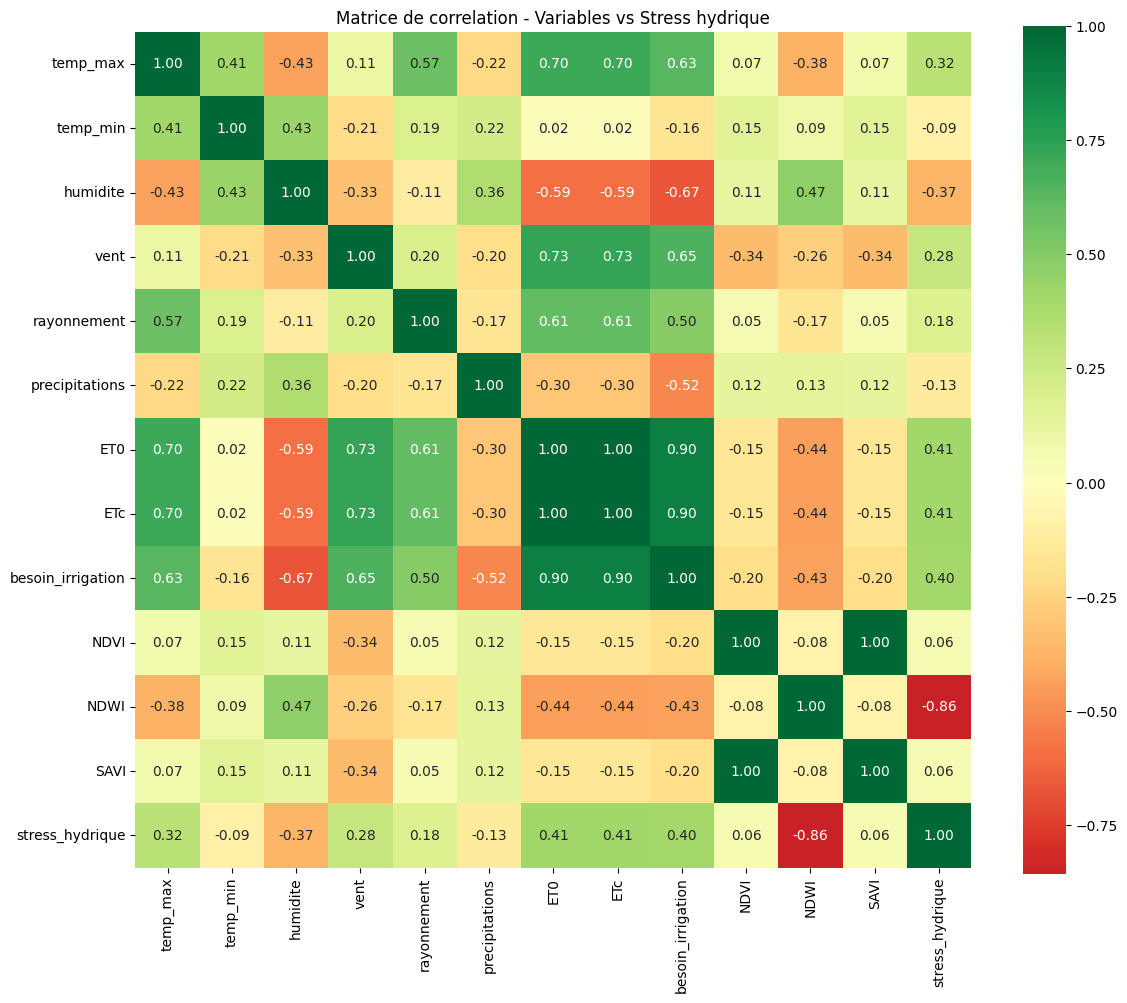


Correlation avec stress_hydrique :
stress_hydrique      1.000000
ET0                  0.409765
ETc                  0.409765
besoin_irrigation    0.400353
temp_max             0.323283
vent                 0.275332
rayonnement          0.177218
NDVI                 0.056080
SAVI                 0.055983
temp_min            -0.093700
precipitations      -0.128442
humidite            -0.366365
NDWI                -0.855829
Name: stress_hydrique, dtype: float64


In [6]:
# Matrice de correlation
features_num = ["temp_max", "temp_min", "humidite", "vent",
                "rayonnement", "precipitations", "ET0", "ETc",
                "besoin_irrigation", "NDVI", "NDWI", "SAVI",
                "stress_hydrique"]

corr = df[features_num].corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdYlGn",
            center=0, square=True)
plt.title("Matrice de correlation - Variables vs Stress hydrique")
plt.tight_layout()
plt.savefig("matrice_correlation.png", dpi=150)
plt.show()

# Correlation specifique avec stress_hydrique
print("\nCorrelation avec stress_hydrique :")
print(corr["stress_hydrique"].sort_values(ascending=False))

- NDWI(-0.856) est de loin la variable la plus corrélée avec le stress
  Logique parfaite — quand NDWI baisse (plantes sèches), le stress monte. C'est ta variable satellitaire la plus puissante.
- ET0, ETc et besoin_irrigation sont très corrélés entre eux :On pourrait en supprimer 2 sans perdre d'information.
- NDVI(0.056) et SAVI(0.056) ont exactement la même corrélation, elles sont identiques (corr = 1.00), donc on
  pourrait supprimer un

### Entrainement du modele avec toutes les variables

In [7]:
features = [
    "temp_max", "temp_min", "humidite", "vent",
    "rayonnement", "precipitations", "ET0", "ETc",
    "besoin_irrigation", "NDVI", "SAVI",
    "ville_encoded"
]

le = LabelEncoder()
df["ville_encoded"] = le.fit_transform(df["ville"])

X = df[features]
y = df["stress_hydrique"]

# Split 80/20
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

#  Entraîner avec Random Forest 
rf = RandomForestClassifier(
    n_estimators = 200,
    max_depth    = 15,
    random_state = 42,
    class_weight = "balanced",
    n_jobs       = -1
)
rf.fit(X_train, y_train)

# Évaluation
y_pred = rf.predict(X_test)
print("=== MODELE COMPLET - TOUTES VARIABLES ===")
print(classification_report(y_test, y_pred,
      target_names=["Faible", "Modere", "Severe"]))

=== MODELE COMPLET - TOUTES VARIABLES ===
              precision    recall  f1-score   support

      Faible       0.85      0.81      0.83       188
      Modere       0.89      0.92      0.90       570
      Severe       0.82      0.72      0.77       118

    accuracy                           0.87       876
   macro avg       0.85      0.82      0.83       876
weighted avg       0.87      0.87      0.87       876



NDWI est supprime des variables car la variable cible est directement derivee de celle-ci, du coup y a un probleme de data leakage

In [8]:
# Calculer les valeurs SHAP
print("Calcul des valeurs SHAP en cours...")
explainer   = shap.TreeExplainer(rf)
shap_values = explainer.shap_values(X_test)

print("Calcul termine !")
print(f"Forme shap_values : {np.array(shap_values).shape}")

Calcul des valeurs SHAP en cours...
Calcul termine !
Forme shap_values : (876, 12, 3)


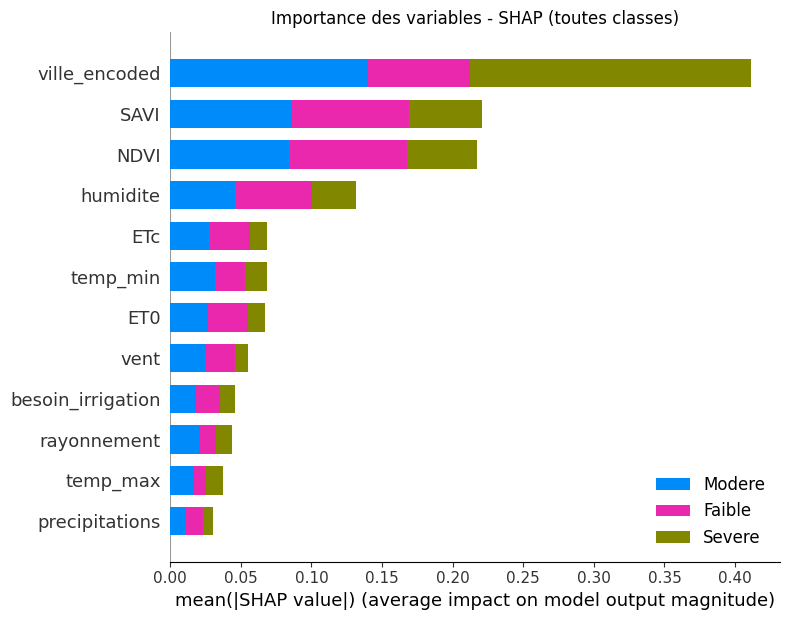

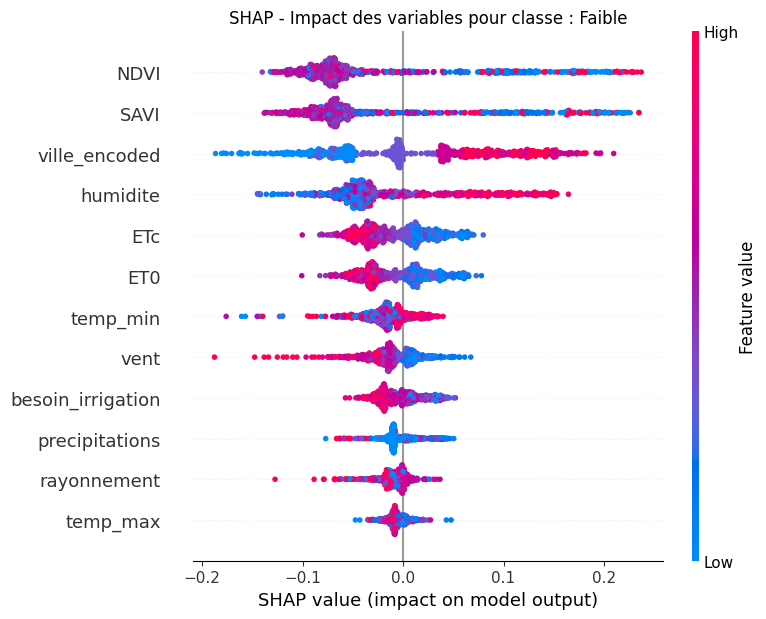

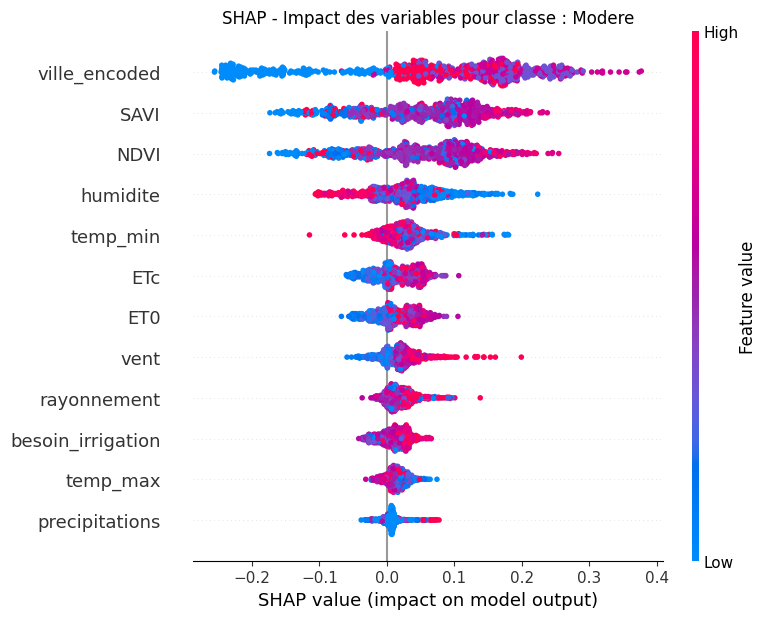

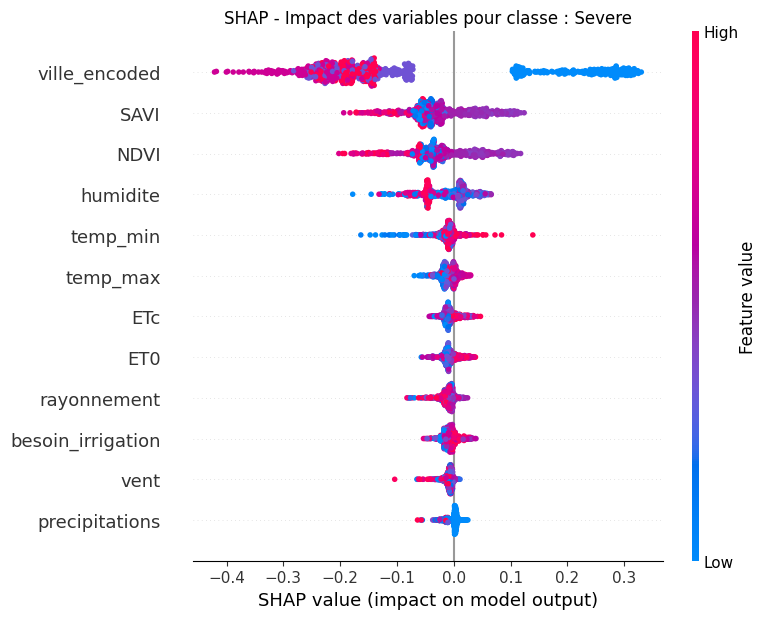


=== IMPORTANCE DES VARIABLES PAR CLASSE ===

Classe Faible :
         variable  importance
             NDVI    0.083334
             SAVI    0.083260
    ville_encoded    0.071936
         humidite    0.054528
              ETc    0.029044
              ET0    0.028418
         temp_min    0.021194
             vent    0.020214
besoin_irrigation    0.016515
   precipitations    0.012899
      rayonnement    0.011256
         temp_max    0.008635

Classe Modere :
         variable  importance
    ville_encoded    0.140126
             SAVI    0.086150
             NDVI    0.084130
         humidite    0.045891
         temp_min    0.031855
              ETc    0.027714
              ET0    0.026936
             vent    0.025603
      rayonnement    0.020935
besoin_irrigation    0.018576
         temp_max    0.016653
   precipitations    0.010297

Classe Severe :
         variable  importance
    ville_encoded    0.199208
             SAVI    0.051412
             NDVI    0.049903
    

In [9]:
# ── GRAPHIQUE 1 - Importance globale des variables ────────────
plt.figure(figsize=(10, 6))
shap.summary_plot(
    shap_values,
    X_test,
    feature_names = features,
    plot_type     = "bar",
    class_names   = ["Faible", "Modere", "Severe"],
    show          = False
)
plt.title("Importance des variables - SHAP (toutes classes)")
plt.tight_layout()
plt.savefig("shap_importance_globale.png", dpi=150)
plt.show()

# ── GRAPHIQUE 2 - Impact détaillé par classe ──────────────────
classes = ["Faible", "Modere", "Severe"]

for i, classe in enumerate(classes):
    plt.figure(figsize=(10, 6))
    shap.summary_plot(
        shap_values[:, :, i],
        X_test,
        feature_names = features,
        show          = False
    )
    plt.title(f"SHAP - Impact des variables pour classe : {classe}")
    plt.tight_layout()
    plt.savefig(f"shap_{classe.lower()}.png", dpi=150)
    plt.show()

# ── GRAPHIQUE 3 - Importance numérique ───────────────────────
print("\n=== IMPORTANCE DES VARIABLES PAR CLASSE ===")
for i, classe in enumerate(classes):
    importance = np.abs(shap_values[:, :, i]).mean(axis=0)
    df_imp = pd.DataFrame({
        "variable"  : features,
        "importance": importance
    }).sort_values("importance", ascending=False)
    print(f"\nClasse {classe} :")
    print(df_imp.to_string(index=False))

1. La localisation géographique est le facteur
   le plus déterminant du stress hydrique
   -> Dagana et Podor structurellement plus à risque

2. Les indices satellitaires (NDVI, SAVI) sont
   plus importants que les variables climatiques
   (ET0, ETc, précipitations)
   -> Justifie l'utilisation de Sentinel-2

3. L'humidité relative est la variable climatique
   la plus importante
   -> Confirme l'importance de la mesure atmosphérique

4. Les précipitations sont peu importantes
   -> Normal en zone irriguée où la pluie est rare

Nombre optimal de variables : 11

Variables retenues :
['temp_max', 'temp_min', 'humidite', 'vent', 'rayonnement', 'ET0', 'ETc', 'besoin_irrigation', 'NDVI', 'SAVI', 'ville_encoded']


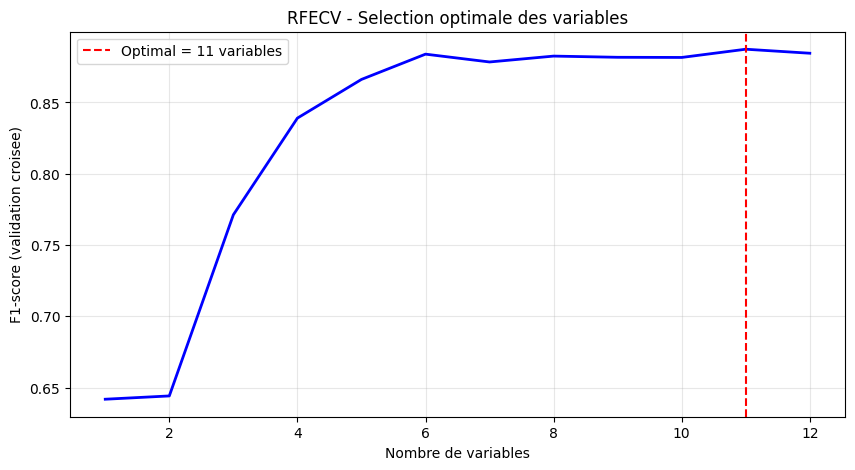

In [10]:
rfecv = RFECV(
    estimator = RandomForestClassifier(
                    n_estimators = 100,
                    random_state = 42,
                    n_jobs       = -1),
    step      = 1,
    cv        = StratifiedKFold(5),
    scoring   = "f1_weighted",
    n_jobs    = -1
)
rfecv.fit(X_train, y_train)

print(f"Nombre optimal de variables : {rfecv.n_features_}")
print(f"\nVariables retenues :")
variables_retenues = [f for f, s in
                      zip(features, rfecv.support_) if s]
print(variables_retenues)

# Graphique
plt.figure(figsize=(10, 5))
plt.plot(range(1, len(rfecv.cv_results_["mean_test_score"]) + 1),
         rfecv.cv_results_["mean_test_score"],
         color="blue", linewidth=2)
plt.axvline(x=rfecv.n_features_, color="red",
            linestyle="--",
            label=f"Optimal = {rfecv.n_features_} variables")
plt.xlabel("Nombre de variables")
plt.ylabel("F1-score (validation croisee)")
plt.title("RFECV - Selection optimale des variables")
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig("rfecv_selection.png", dpi=150)
plt.show()

=== MODELE FINAL OPTIMISE - 11 VARIABLES ===
              precision    recall  f1-score   support

      Faible       0.86      0.82      0.84       188
      Modere       0.89      0.91      0.90       570
      Severe       0.79      0.73      0.76       118

    accuracy                           0.87       876
   macro avg       0.84      0.82      0.83       876
weighted avg       0.87      0.87      0.87       876


=== COMPARAISON ===
Modele complet  (12 variables) : accuracy = 0.87
Modele optimise (11 variables) : accuracy = 0.87


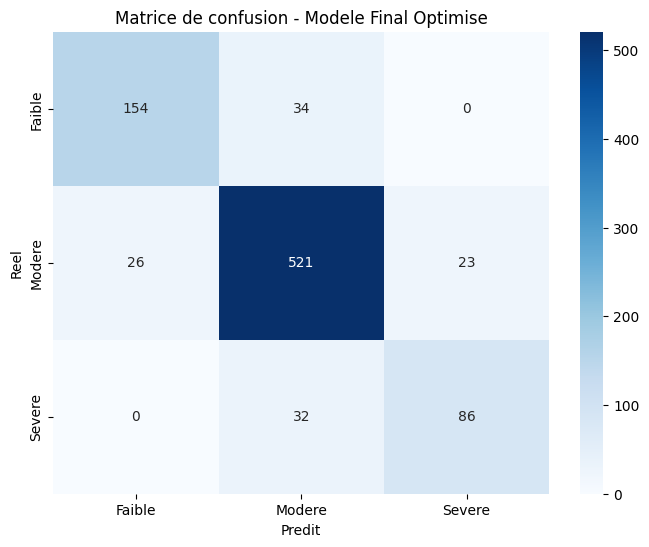

In [11]:
# Variables optimales selon RFECV
features_optimales = [
    "temp_max", "temp_min", "humidite", "vent",
    "rayonnement", "ET0", "ETc", "besoin_irrigation",
    "NDVI", "SAVI", "ville_encoded"
]

X_opt       = df[features_optimales]
y_opt       = df["stress_hydrique"]

X_train_opt, X_test_opt, y_train_opt, y_test_opt = train_test_split(
    X_opt, y_opt, test_size=0.2, random_state=42, stratify=y_opt
)

# Modele final optimise
rf_final = RandomForestClassifier(
    n_estimators = 200,
    max_depth    = 15,
    random_state = 42,
    class_weight = "balanced",
    n_jobs       = -1
)
rf_final.fit(X_train_opt, y_train_opt)

y_pred_opt = rf_final.predict(X_test_opt)

print("=== MODELE FINAL OPTIMISE - 11 VARIABLES ===")
print(classification_report(y_test_opt, y_pred_opt,
      target_names=["Faible", "Modere", "Severe"]))

# Comparaison avant/apres RFECV
print("\n=== COMPARAISON ===")
print(f"Modele complet  (12 variables) : accuracy = 0.87")
from sklearn.metrics import accuracy_score
acc_opt = accuracy_score(y_test_opt, y_pred_opt)
print(f"Modele optimise (11 variables) : accuracy = {acc_opt:.2f}")

# Matrice de confusion finale
cm = confusion_matrix(y_test_opt, y_pred_opt)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Faible", "Modere", "Severe"],
            yticklabels=["Faible", "Modere", "Severe"])
plt.title("Matrice de confusion - Modele Final Optimise")
plt.ylabel("Reel")
plt.xlabel("Predit")
plt.savefig("matrice_confusion_final.png", dpi=150)
plt.show()

In [13]:
# XGBoost
xgb = XGBClassifier(
    n_estimators     = 200,
    max_depth        = 6,
    learning_rate    = 0.1,
    random_state     = 42,
    eval_metric      = "mlogloss",
    n_jobs           = -1
)
xgb.fit(X_train_opt, y_train_opt)

y_pred_xgb = xgb.predict(X_test_opt)

print("=== XGBOOST ===")
print(classification_report(y_test_opt, y_pred_xgb,
      target_names=["Faible", "Modere", "Severe"]))

# Tableau comparatif
print("\n=== COMPARAISON MODELES ===")
print(f"{'Modele':<20} {'Accuracy':>10} {'F1 Faible':>10} {'F1 Modere':>10} {'F1 Severe':>10}")
print("-" * 65)

from sklearn.metrics import f1_score
# Random Forest
f1_rf = f1_score(y_test_opt, y_pred_opt, average=None)
print(f"{'Random Forest':<20} {'0.87':>10} {f1_rf[0]:>10.2f} {f1_rf[1]:>10.2f} {f1_rf[2]:>10.2f}")

# XGBoost
acc_xgb = accuracy_score(y_test_opt, y_pred_xgb)
f1_xgb  = f1_score(y_test_opt, y_pred_xgb, average=None)
print(f"{'XGBoost':<20} {acc_xgb:>10.2f} {f1_xgb[0]:>10.2f} {f1_xgb[1]:>10.2f} {f1_xgb[2]:>10.2f}")

=== XGBOOST ===
              precision    recall  f1-score   support

      Faible       0.85      0.84      0.85       188
      Modere       0.90      0.91      0.91       570
      Severe       0.80      0.75      0.78       118

    accuracy                           0.88       876
   macro avg       0.85      0.84      0.84       876
weighted avg       0.88      0.88      0.88       876


=== COMPARAISON MODELES ===
Modele                 Accuracy  F1 Faible  F1 Modere  F1 Severe
-----------------------------------------------------------------
Random Forest              0.87       0.84       0.90       0.76
XGBoost                    0.88       0.85       0.91       0.78


In [14]:
# Sauvegarder XGBoost comme modele final
joblib.dump(xgb, "modele_xgboost_final.pkl")
print("XGBoost sauvegarde !")

XGBoost sauvegarde !
